
BRENK, NIH and PAINS FILTERS

Please upload your compound file (CSV format)
The file should contain at least compound_name and smiles columns.


Saving filtered_drug_like_compounds.csv to filtered_drug_like_compounds.csv
Using uploaded file: filtered_drug_like_compounds.csv

Using 'compound_name' as compound names and 'smiles' as SMILES

Adding molecule representations...


Failed to patch pandas - unable to change molecule rendering



Dataset shape: (17611, 3)
Number of compounds: 17611

Visualizing example molecules from the dataset:


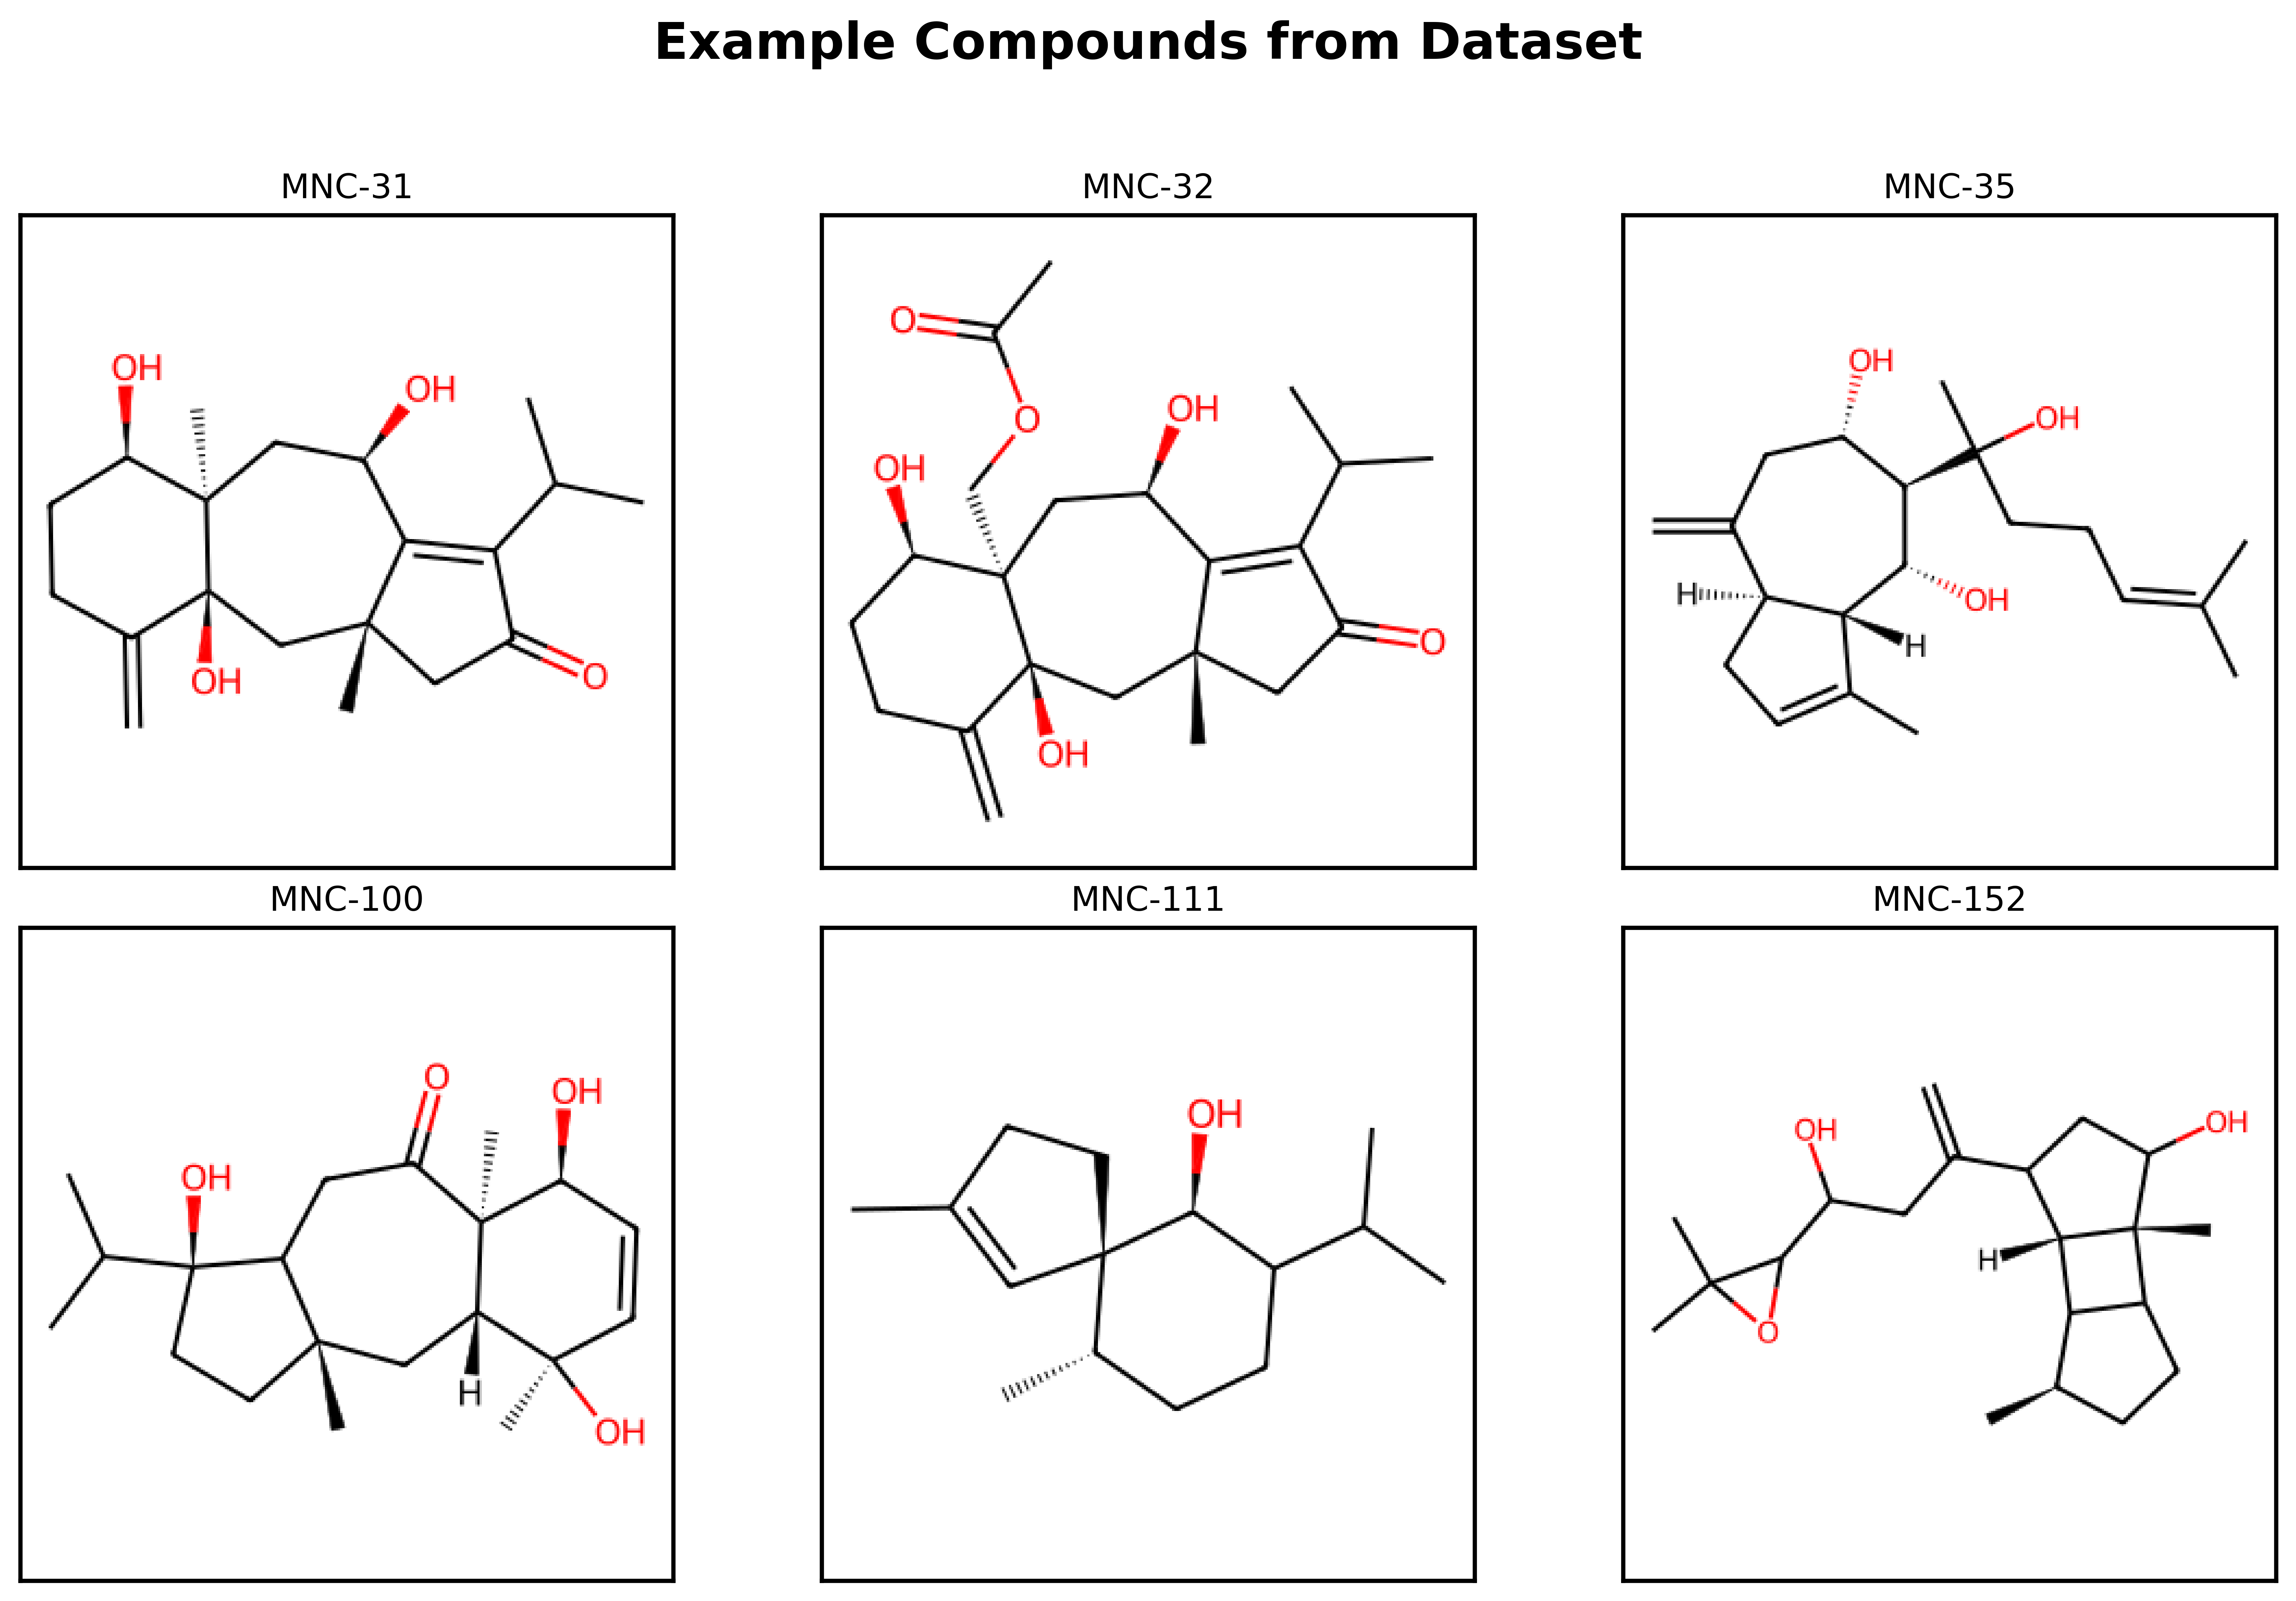



STEP 1: Applying Brenk Filter


Applying Brenk filter:   0%|          | 0/17611 [00:00<?, ?it/s]


Removed 11547 compounds using Brenk filter.
Remaining compounds: 6064


STEP 2: Applying NIH Filter


Applying NIH filter:   0%|          | 0/6064 [00:00<?, ?it/s]


Removed 36 compounds using NIH filter.
Remaining compounds: 6028


STEP 3: Filtering for PAINS


Checking for PAINS:   0%|          | 0/6028 [00:00<?, ?it/s]


Number of compounds with PAINS: 255
Number of compounds without PAINS: 5773


SUMMARY: BRENK, NIH and PAINS Filters Results

Original dataset: 17611 compounds

Filtering steps:
- Brenk: Removed 11547 compounds (65.57%), 6064 remaining
- NIH: Removed 36 compounds (0.59%), 6028 remaining
- PAINS: Removed 255 compounds (4.23%), 5773 remaining

Final dataset: 5773 compounds (32.78% of original)


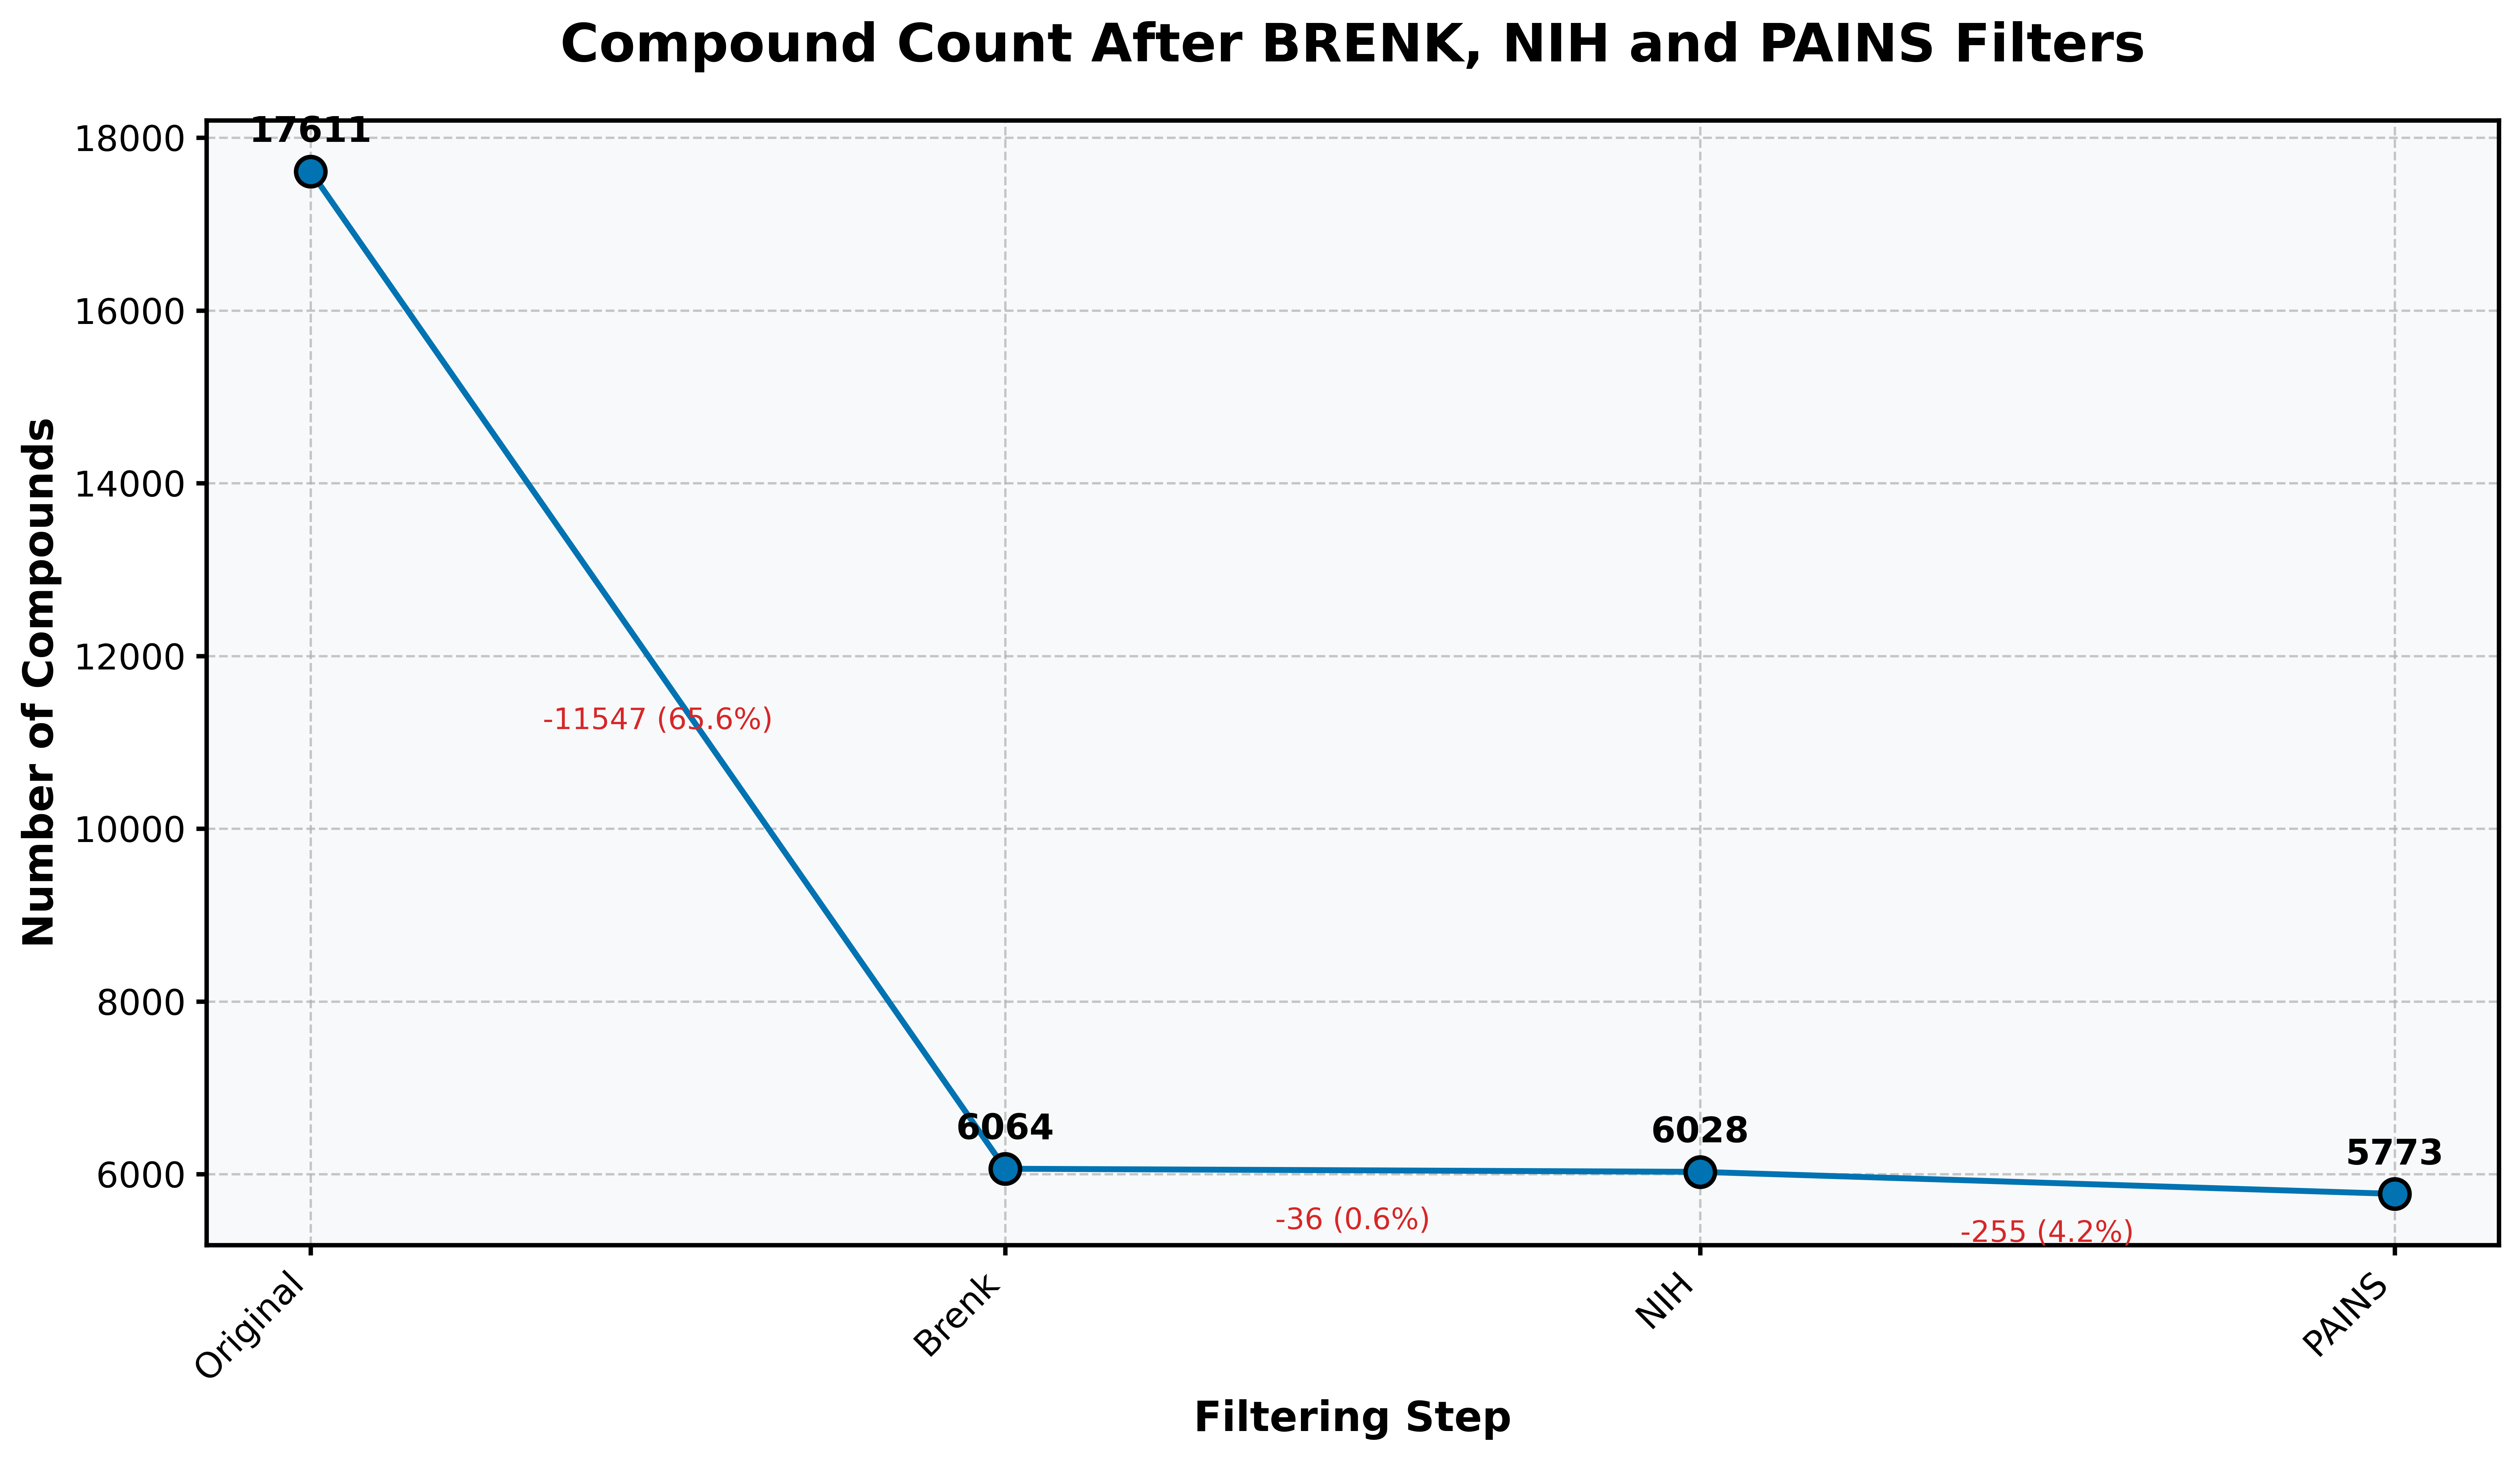

/tmp/ipython-input-2-3616124340.py:279: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_yticklabels(ylabels)




SAVING AND DOWNLOADING RESULTS

Saved 5773 filtered compounds to /content/filtered_compounds/BRENK, NIH and PAINS_filtered_compounds.csv

Preparing filtered compounds for download...

Created zip file with all results: /content/BRENK, NIH and PAINS_filter_results.zip


/usr/lib/python3.11/zipfile.py:1567: UserWarning: Duplicate name: 'BRENK, NIH and PAINS_filtered_compounds.csv'
  return self._open_to_write(zinfo, force_zip64=force_zip64)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


BRENK, NIH and PAINS filtering COMPLETE

You can find all output files in the '/content/filtered_compounds/' directory.
The filtered compounds and a zip file with all results have been downloaded to your computer.


In [ ]:
# @title Final_BRENK, NIH and PAINS FILTERS
# Install required packages if not already installed
try:
    import rdkit
except ImportError:
    !pip install rdkit-pypi tqdm seaborn ipywidgets matplotlib-venn -q

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Draw, PandasTools, Descriptors
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams
from pathlib import Path
from tqdm.auto import tqdm
import io
import os
from google.colab import files
from matplotlib_venn import venn3, venn3_circles
from matplotlib.gridspec import GridSpec

# Set publication-quality plot style
plt.rcParams['figure.dpi'] = 600
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 18
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.7

# Create a custom color palette for scientific publication
scientific_palette = sns.color_palette("colorblind", 10)
sns.set_palette(scientific_palette)

# Create output directory
output_dir = Path('/content/filtered_compounds')
output_dir.mkdir(exist_ok=True)

# Function to visualize molecules
def visualize_molecules(molecules, labels, title, n_cols=3, mol_size=(300, 300),
                        figsize=(12, 8), highlight_atoms=None):
    """Visualize a list of molecules in a grid with labels"""
    if not molecules:
        print(f"No molecules to visualize for: {title}")
        return

    n_mols = len(molecules)
    n_rows = (n_mols + n_cols - 1) // n_cols

    # Create figure
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    fig.suptitle(title, fontsize=18, fontweight='bold')

    # Ensure axes is always a 2D array
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1 or n_cols == 1:
        axes = axes.reshape(n_rows, n_cols)

    # Draw molecules
    for i in range(n_rows):
        for j in range(n_cols):
            idx = i * n_cols + j
            if idx < n_mols:
                mol = molecules[idx]
                label = labels[idx]

                # Convert mol to image and display
                img = Draw.MolToImage(mol, size=mol_size)
                axes[i, j].imshow(img)
                axes[i, j].set_title(label, fontsize=12)

            # Remove axis ticks
            axes[i, j].set_xticks([])
            axes[i, j].set_yticks([])

            # Hide empty subplots
            if idx >= n_mols:
                axes[i, j].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    return fig

# Function to create filter summary plot
def create_filter_summary_plot(filter_stages, counts, title="Compound Count After Each Filtering Step"):
    """Create a summary plot of filtering steps"""
    fig, ax = plt.subplots(figsize=(12, 7))

    # Create x positions for the plot
    x_positions = np.arange(len(filter_stages))

    # Plot the data
    ax.plot(x_positions, counts, 'o-', markersize=10, linewidth=2,
            color=scientific_palette[0], markeredgecolor='black', markeredgewidth=1.5)

    # Add data labels
    for i, (x, y) in enumerate(zip(x_positions, counts)):
        ax.annotate(f"{y}", (x, y), textcoords="offset points",
                   xytext=(0, 10), ha='center', fontsize=12, fontweight='bold')

    # Add percentage labels for reduction
    for i in range(1, len(counts)):
        reduction = counts[i-1] - counts[i]
        percent = (reduction / counts[i-1]) * 100
        midpoint_y = (counts[i-1] + counts[i]) / 2
        midpoint_x = (x_positions[i-1] + x_positions[i]) / 2
        ax.annotate(f"-{reduction} ({percent:.1f}%)",
                   (midpoint_x, midpoint_y),
                   textcoords="offset points", xytext=(0, -20),
                   ha='center', fontsize=10, color='#D62728')

    # Customize the plot
    ax.set_title(title, fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel('Filtering Step', fontsize=14, fontweight='bold')
    ax.set_ylabel('Number of Compounds', fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.7)

    # Set the x-tick positions and labels
    ax.set_xticks(x_positions)
    ax.set_xticklabels(filter_stages, rotation=45, ha='right')

    # Add a subtle background color
    ax.set_facecolor('#f8f9fa')

    # Add a box around the plot
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1.5)

    plt.tight_layout()
    return fig

# Function to create publication-quality distribution plots
def create_distribution_plots(original_count, brenk_matches, nih_matches, pains_matches, filtered_data,
                             brenk_indices, nih_indices, pains_indices, passed_indices):
    """Create publication-quality distribution plots for BRENK, NIH and PAINS filters"""

    # Create a figure with multiple subplots using GridSpec
    fig = plt.figure(figsize=(16, 14))
    gs = GridSpec(2, 2, figure=fig, height_ratios=[1, 1], width_ratios=[1, 1])

    # 1. Pie chart showing overall distribution
    ax1 = fig.add_subplot(gs[0, 0])

    # Calculate counts for pie chart
    filtered_counts = {
        'Passed All Filters': len(filtered_data),
        'Failed BRENK': len(brenk_matches),
        'Failed NIH': len(nih_matches),
        'Failed PAINS': len(pains_matches)
    }

    # Create a custom color map for the pie chart
    colors = [scientific_palette[2], scientific_palette[0], scientific_palette[1], scientific_palette[3]]

    # Create the pie chart
    wedges, texts, autotexts = ax1.pie(
        filtered_counts.values(),
        labels=filtered_counts.keys(),
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        wedgeprops={'edgecolor': 'black', 'linewidth': 1.5, 'antialiased': True},
        textprops={'fontsize': 12, 'fontweight': 'bold'}
    )

    # Customize the pie chart text
    for autotext in autotexts:
        autotext.set_fontsize(10)
        autotext.set_fontweight('bold')

    ax1.set_title('Distribution of Compounds After Filtering', fontsize=16, fontweight='bold', pad=20)

    # 2. Venn diagram showing overlap between filters
    ax2 = fig.add_subplot(gs[0, 1])

    # Convert indices to sets for Venn diagram
    brenk_set = set(brenk_indices)
    nih_set = set(nih_indices)
    pains_set = set(pains_indices)

    # Create the Venn diagram
    venn = venn3([brenk_set, nih_set, pains_set],
                ('BRENK', 'NIH', 'PAINS'),
                ax=ax2,
                set_colors=(scientific_palette[0], scientific_palette[1], scientific_palette[3]))

    # Customize Venn diagram
    for text in venn.set_labels:
        if text is not None:
            text.set_fontsize(14)
            text.set_fontweight('bold')

    for text in venn.subset_labels:
        if text is not None:
            text.set_fontsize(12)
            text.set_fontweight('bold')

    # Add circles with black edges
    venn3_circles([brenk_set, nih_set, pains_set], ax=ax2, linewidth=1.5, color='black')

    ax2.set_title('Overlap Between Different Filters', fontsize=16, fontweight='bold', pad=20)

    # 3. Horizontal bar chart showing filter-specific counts
    ax3 = fig.add_subplot(gs[1, 0])

    # Get the top filter descriptions for each filter type
    filter_descriptions = {}

    if len(brenk_matches) > 0:
        brenk_df = pd.DataFrame(brenk_matches)
        filter_descriptions['BRENK'] = brenk_df['filter_description'].value_counts().head(5)

    if len(nih_matches) > 0:
        nih_df = pd.DataFrame(nih_matches)
        filter_descriptions['NIH'] = nih_df['filter_description'].value_counts().head(5)

    if len(pains_matches) > 0:
        pains_df = pd.DataFrame(pains_matches)
        filter_descriptions['PAINS'] = pains_df['pains'].value_counts().head(5)

    # Combine all filter descriptions
    all_descriptions = []
    for filter_type, descriptions in filter_descriptions.items():
        for desc, count in descriptions.items():
            all_descriptions.append({
                'Filter': filter_type,
                'Description': desc,
                'Count': count
            })

    if all_descriptions:
        desc_df = pd.DataFrame(all_descriptions)

        # Sort by count
        desc_df = desc_df.sort_values('Count', ascending=True)

        # Create a horizontal bar chart
        colors = {'BRENK': scientific_palette[0], 'NIH': scientific_palette[1], 'PAINS': scientific_palette[3]}

        # Plot bars
        bars = sns.barplot(x='Count', y='Description', hue='Filter', data=desc_df,
                          palette=colors, dodge=False, ax=ax3)

        # Add count labels to the bars
        for i, p in enumerate(bars.patches):
            width = p.get_width()
            ax3.text(width + 0.5, p.get_y() + p.get_height()/2,
                    f"{int(width)}", ha='left', va='center', fontweight='bold')

        # Customize the plot
        ax3.set_title('Top Structural Alerts by Filter Type', fontsize=16, fontweight='bold', pad=20)
        ax3.set_xlabel('Number of Compounds', fontsize=14, fontweight='bold')
        ax3.set_ylabel('Structural Alert', fontsize=14, fontweight='bold')

        # Adjust legend
        ax3.legend(title='Filter Type', title_fontsize=12, fontsize=10, loc='lower right')

        # Truncate long descriptions
        ylabels = [label.get_text()[:40] + '...' if len(label.get_text()) > 40 else label.get_text()
                  for label in ax3.get_yticklabels()]
        ax3.set_yticklabels(ylabels)
    else:
        ax3.text(0.5, 0.5, "No filter matches to display",
                ha='center', va='center', fontsize=14, fontweight='bold')
        ax3.axis('off')

    # 4. Stacked bar chart showing progression of filtering
    ax4 = fig.add_subplot(gs[1, 1])

    # Create data for stacked bar chart
    stages = ['Original', 'After BRENK', 'After NIH', 'After PAINS']

    # Calculate the number of compounds at each stage
    original = original_count
    after_brenk = filtering_stats["After Filters"].get("Brenk", original)
    after_nih = filtering_stats["After Filters"].get("NIH", after_brenk)
    after_pains = filtering_stats["After Filters"].get("PAINS", after_nih)

    # Calculate the number of compounds removed at each stage
    removed_brenk = original - after_brenk
    removed_nih = after_brenk - after_nih
    removed_pains = after_nih - after_pains

    # Create stacked bar data
    passed = [original, after_brenk, after_nih, after_pains]
    removed = [0, removed_brenk, removed_nih, removed_pains]

    # Create the stacked bar chart
    ax4.bar(stages, passed, label='Passed', color=scientific_palette[2], edgecolor='black', linewidth=1.5)
    ax4.bar(stages, removed, bottom=passed, label='Removed', color=scientific_palette[7],
           edgecolor='black', linewidth=1.5, alpha=0.7)

    # Add percentage labels
    for i, (p, r) in enumerate(zip(passed, removed)):
        total = p + r
        if total > 0:
            # Label for passed
            if p > 0:
                percent_p = (p / total) * 100
                ax4.text(i, p/2, f"{percent_p:.1f}%", ha='center', va='center',
                        fontsize=10, fontweight='bold', color='white')

            # Label for removed
            if r > 0:
                percent_r = (r / total) * 100
                ax4.text(i, p + r/2, f"{percent_r:.1f}%", ha='center', va='center',
                        fontsize=10, fontweight='bold', color='black')

    # Customize the plot
    ax4.set_title('Progression of Compound Filtering', fontsize=16, fontweight='bold', pad=20)
    ax4.set_xlabel('Filtering Stage', fontsize=14, fontweight='bold')
    ax4.set_ylabel('Number of Compounds', fontsize=14, fontweight='bold')
    ax4.legend(fontsize=12)

    # Add count labels on top of bars
    for i, (p, r) in enumerate(zip(passed, removed)):
        total = p + r
        ax4.text(i, total + 5, str(total), ha='center', va='bottom', fontsize=12, fontweight='bold')

    # Adjust layout and spacing
    plt.tight_layout()
    fig.subplots_adjust(hspace=0.3, wspace=0.3)

    # Add a title for the entire figure
    fig.suptitle('BRENK, NIH and PAINS Filters: Comprehensive Analysis',
                fontsize=20, fontweight='bold', y=0.98)

    # Add padding for the suptitle
    plt.subplots_adjust(top=0.92)

    return fig

# Print header
print("\n" + "="*80)
print("BRENK, NIH and PAINS FILTERS")
print("="*80)

# Upload file
print("\nPlease upload your compound file (CSV format)")
print("The file should contain at least compound_name and smiles columns.")
uploaded = files.upload()

if uploaded:
    # Use the first uploaded file as the dataset
    filename = list(uploaded.keys())[0]
    print(f"Using uploaded file: {filename}")

    # Read the data
    compounds_data = pd.read_csv(io.BytesIO(uploaded[filename]))

    # Check columns and rename if needed
    columns = compounds_data.columns.tolist()

    # Try to identify SMILES column
    smiles_col = None
    for col in columns:
        if col.lower() in ['smiles', 'smi', 'canonical_smiles']:
            smiles_col = col
            break

    if smiles_col is None:
        # If no obvious SMILES column, use the second column
        if len(columns) >= 2:
            smiles_col = columns[1]
        else:
            smiles_col = columns[0]

    # Try to identify compound name column
    name_col = None
    for col in columns:
        if col.lower() in ['compound_name', 'name', 'id', 'cid', 'compound_id']:
            name_col = col
            break

    if name_col is None:
        # If no obvious name column, use the first column
        name_col = columns[0]

    # Create a standardized dataframe
    filtered_data = pd.DataFrame({
        'CIDs': compounds_data[name_col],
        'smiles': compounds_data[smiles_col]
    })

    print(f"\nUsing '{name_col}' as compound names and '{smiles_col}' as SMILES")

    # Add molecule column to the dataframe
    print("\nAdding molecule representations...")
    PandasTools.AddMoleculeColumnToFrame(filtered_data, smilesCol="smiles")

    # Display dataset info
    original_count = len(filtered_data)
    print(f"\nDataset shape: {filtered_data.shape}")
    print(f"Number of compounds: {original_count}")

    # Display a few example molecules
    print("\nVisualizing example molecules from the dataset:")
    valid_mols = [mol for mol in filtered_data.head(6).ROMol.tolist() if mol is not None]
    if valid_mols:
        example_mols = valid_mols[:6]
        example_labels = filtered_data.head(len(example_mols))["CIDs"].astype(str).tolist()
        fig = visualize_molecules(example_mols, example_labels, "Example Compounds from Dataset", n_cols=3)
        plt.savefig(output_dir / "example_compounds.png", dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print("Warning: No valid molecules found in the first 6 entries. Check your SMILES strings.")

    # Create a tracking dictionary for reporting
    filtering_stats = {
        "Original": len(filtered_data),
        "After Filters": {}
    }

    # Track indices of compounds filtered by each filter for the Venn diagram
    all_indices = set(filtered_data.index.tolist())
    brenk_filtered_indices = set()
    nih_filtered_indices = set()
    pains_filtered_indices = set()

    # =============================================
    # Apply Brenk Filter (FIRST)
    # =============================================
    print("\n\n" + "="*80)
    print("STEP 1: Applying Brenk Filter")
    print("="*80)

    # Initialize the Brenk filter
    brenk_params = FilterCatalogParams()
    brenk_params.AddCatalog(FilterCatalogParams.FilterCatalogs.BRENK)
    brenk_catalog = FilterCatalog(brenk_params)

    # Apply Brenk filter
    brenk_matches = []
    brenk_clean_indices = []
    for index, row in tqdm(filtered_data.iterrows(), total=filtered_data.shape[0], desc="Applying Brenk filter"):
        molecule = row.ROMol
        if molecule is not None:
            entry = brenk_catalog.GetFirstMatch(molecule)
            if entry is not None:
                brenk_matches.append({
                    "id": row["CIDs"],
                    "smiles": row["smiles"],
                    "rdkit_molecule": molecule,
                    "filter_description": entry.GetDescription()
                })
                brenk_filtered_indices.add(index)
            else:
                brenk_clean_indices.append(index)

    # Save the Brenk matches
    brenk_matches_df = pd.DataFrame(brenk_matches) if brenk_matches else pd.DataFrame()
    if not brenk_matches_df.empty:
        # Drop the RDKit molecule column for saving
        save_df = brenk_matches_df.copy()
        if 'rdkit_molecule' in save_df.columns:
            save_df = save_df.drop('rdkit_molecule', axis=1)
        save_df.to_csv(output_dir / "brenk_filtered_compounds.csv", index=False)

    # Keep only compounds that passed Brenk filter
    filtered_data = filtered_data.loc[brenk_clean_indices]
    filtering_stats["After Filters"]["Brenk"] = len(filtered_data)
    print(f"\nRemoved {len(brenk_matches)} compounds using Brenk filter.")
    print(f"Remaining compounds: {len(filtered_data)}")

    # =============================================
    # Apply NIH Filter (SECOND)
    # =============================================
    print("\n\n" + "="*80)
    print("STEP 2: Applying NIH Filter")
    print("="*80)

    # Initialize NIH filter
    nih_params = FilterCatalogParams()
    nih_params.AddCatalog(FilterCatalogParams.FilterCatalogs.NIH)
    nih_catalog = FilterCatalog(nih_params)

    # Apply NIH filter
    nih_matches = []
    nih_clean_indices = []
    for index, row in tqdm(filtered_data.iterrows(), total=filtered_data.shape[0], desc="Applying NIH filter"):
        molecule = row.ROMol
        if molecule is not None:
            entry = nih_catalog.GetFirstMatch(molecule)
            if entry is not None:
                nih_matches.append({
                    "id": row["CIDs"],
                    "smiles": row["smiles"],
                    "rdkit_molecule": molecule,
                    "filter_description": entry.GetDescription()
                })
                nih_filtered_indices.add(index)
            else:
                nih_clean_indices.append(index)

    # Save the NIH matches
    nih_matches_df = pd.DataFrame(nih_matches) if nih_matches else pd.DataFrame()
    if not nih_matches_df.empty:
        # Drop the RDKit molecule column for saving
        save_df = nih_matches_df.copy()
        if 'rdkit_molecule' in save_df.columns:
            save_df = save_df.drop('rdkit_molecule', axis=1)
        save_df.to_csv(output_dir / "nih_filtered_compounds.csv", index=False)

    # Keep only compounds that passed NIH filter
    filtered_data = filtered_data.loc[nih_clean_indices]
    filtering_stats["After Filters"]["NIH"] = len(filtered_data)
    print(f"\nRemoved {len(nih_matches)} compounds using NIH filter.")
    print(f"Remaining compounds: {len(filtered_data)}")

    # =============================================
    # Filter for PAINS (THIRD)
    # =============================================
    print("\n\n" + "="*80)
    print("STEP 3: Filtering for PAINS")
    print("="*80)

    # Initialize PAINS filter
    pains_params = FilterCatalogParams()
    pains_params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
    pains_catalog = FilterCatalog(pains_params)

    # Search for PAINS
    pains_matches = []
    pains_clean_indices = []
    for index, row in tqdm(filtered_data.iterrows(), total=filtered_data.shape[0], desc="Checking for PAINS"):
        molecule = row.ROMol
        if molecule is not None:
            entry = pains_catalog.GetFirstMatch(molecule)
            if entry is not None:
                pains_matches.append({
                    "id": row["CIDs"],
                    "smiles": row["smiles"],
                    "rdkit_molecule": molecule,
                    "pains": entry.GetDescription()
                })
                pains_filtered_indices.add(index)
            else:
                pains_clean_indices.append(index)

    # Create a DataFrame of PAINS matches
    pains_matches_df = pd.DataFrame(pains_matches) if pains_matches else pd.DataFrame()
    if not pains_matches_df.empty:
        # Drop the RDKit molecule column for saving
        save_df = pains_matches_df.copy()
        if 'rdkit_molecule' in save_df.columns:
            save_df = save_df.drop('rdkit_molecule', axis=1)
        save_df.to_csv(output_dir / "pains_compounds.csv", index=False)

    print(f"\nNumber of compounds with PAINS: {len(pains_matches)}")
    filtered_data = filtered_data.loc[pains_clean_indices]
    filtering_stats["After Filters"]["PAINS"] = len(filtered_data)
    print(f"Number of compounds without PAINS: {len(filtered_data)}")

    # Calculate indices of compounds that passed all filters
    passed_indices = set(pains_clean_indices)

    # =============================================
    # Summary Report
    # =============================================
    print("\n\n" + "="*80)
    print("SUMMARY: BRENK, NIH and PAINS Filters Results")
    print("="*80)

    # Print filtering statistics
    print(f"\nOriginal dataset: {original_count} compounds")
    print("\nFiltering steps:")
    current_count = original_count
    for filter_name, count in filtering_stats["After Filters"].items():
        removed = current_count - count
        removed_percent = (removed / current_count) * 100 if current_count > 0 else 0
        print(f"- {filter_name}: Removed {removed} compounds ({removed_percent:.2f}%), {count} remaining")
        current_count = count

    print(f"\nFinal dataset: {len(filtered_data)} compounds ({len(filtered_data)/original_count*100:.2f}% of original)")

    # Visualize the filtering process
    filter_stages = ['Original'] + list(filtering_stats["After Filters"].keys())
    counts = [original_count] + list(filtering_stats["After Filters"].values())

    fig = create_filter_summary_plot(filter_stages, counts, "Compound Count After BRENK, NIH and PAINS Filters")
    plt.savefig(output_dir / "BRENK, NIH and PAINS_filters_summary.png", dpi=600, bbox_inches='tight')
    plt.show()

    # Create publication-quality distribution plots
    dist_fig = create_distribution_plots(
        original_count,
        brenk_matches,
        nih_matches,
        pains_matches,
        filtered_data,
        brenk_filtered_indices,
        nih_filtered_indices,
        pains_filtered_indices,
        passed_indices
    )

    # Save the distribution plots
    plt.savefig(output_dir / "BRENK, NIH and PAINS_filters_distribution.png", dpi=600, bbox_inches='tight')
    plt.savefig(output_dir / "BRENK, NIH and PAINS_filters_distribution.pdf", bbox_inches='tight')
    plt.savefig(output_dir / "BRENK, NIH and PAINS_distribution.svg", bbox_inches='tight')
    plt.show()

    # =============================================
    # Save and Download Results
    # =============================================
    print("\n\n" + "="*80)
    print("SAVING AND DOWNLOADING RESULTS")
    print("="*80)

    # Save the filtered dataset
    filtered_data_file = output_dir / "BRENK, NIH and PAINS_filtered_compounds.csv"
    # Remove RDKit molecule column before saving
    if 'ROMol' in filtered_data.columns:
        filtered_data = filtered_data.drop('ROMol', axis=1)
    filtered_data.to_csv(filtered_data_file, index=False)
    print(f"\nSaved {len(filtered_data)} filtered compounds to {filtered_data_file}")

    # Create a file for download
    download_file = '/content/BRENK, NIH and PAINS_filtered_compounds.csv'
    filtered_data.to_csv(download_file, index=False)
    print("\nPreparing filtered compounds for download...")

    # Create a zip file with all results
    import zipfile

    zip_path = '/content/BRENK, NIH and PAINS_filter_results.zip'
    with zipfile.ZipFile(zip_path, 'w') as zipf:
        # Add filtered compounds
        zipf.write(download_file, arcname='BRENK, NIH and PAINS_filtered_compounds.csv')

        # Add all plots and reports from the output directory
        for file_path in output_dir.glob('*.png'):
            zipf.write(file_path, arcname=file_path.name)

        # Add vector formats for publication
        for file_path in output_dir.glob('*.pdf'):
            zipf.write(file_path, arcname=file_path.name)

        for file_path in output_dir.glob('*.svg'):
            zipf.write(file_path, arcname=file_path.name)

        # Add filtered compounds by filter type
        for file_path in output_dir.glob('*.csv'):
            zipf.write(file_path, arcname=file_path.name)

    print(f"\nCreated zip file with all results: {zip_path}")
    print("Downloading results to your computer...")

    # Download the filtered compounds and the zip file with all results
    files.download(download_file)
    files.download(zip_path)

    print("\n" + "="*80)
    print("BRENK, NIH and PAINS filtering COMPLETE")
    print("="*80)
    print("\nYou can find all output files in the '/content/filtered_compounds/' directory.")
    print("The filtered compounds and a zip file with all results have been downloaded to your computer.")
else:
    print("No file was uploaded. Please run the cell again and upload a file.")



In [ ]:
# Define the summary text template
summary_text = """
========================================
BRENK, NIH and PAINS Filters Summary
========================================

Original number of compounds: {original_count}

Filtering Steps:
----------------------------------------
1. BRENK Filter:
   - Removed: {removed_brenk} compounds ({removed_brenk_percent:.2f}%)
   - Remaining: {after_brenk} compounds

2. NIH Filter:
   - Removed: {removed_nih} compounds ({removed_nih_percent:.2f}%)
   - Remaining: {after_nih} compounds

3. PAINS Filter:
   - Removed: {removed_pains} compounds ({removed_pains_percent:.2f}%)
   - Remaining: {after_pains} compounds

----------------------------------------
Final filtered dataset: {final_count} compounds ({final_percent:.2f}% of original)

All results, including detailed filter matches, plots, and the final dataset, can be found in the '/content/filtered_compounds/' directory and have been downloaded to your computer in the zip file.
"""

# Format the summary with the calculated values
final_count = len(filtered_data)
final_percent = (final_count / original_count) * 100 if original_count > 0 else 0

after_brenk = filtering_stats["After Filters"].get("Brenk", original_count)
removed_brenk = original_count - after_brenk
removed_brenk_percent = (removed_brenk / original_count) * 100 if original_count > 0 else 0

after_nih = filtering_stats["After Filters"].get("NIH", after_brenk)
removed_nih = after_brenk - after_nih
removed_nih_percent = (removed_nih / after_brenk) * 100 if after_brenk > 0 else 0

after_pains = filtering_stats["After Filters"].get("PAINS", after_nih)
removed_pains = after_nih - after_pains
removed_pains_percent = (removed_pains / after_nih) * 100 if after_nih > 0 else 0


formatted_summary = summary_text.format(
    original_count=original_count,
    removed_brenk=removed_brenk,
    removed_brenk_percent=removed_brenk_percent,
    after_brenk=after_brenk,
    removed_nih=removed_nih,
    removed_nih_percent=removed_nih_percent,
    after_nih=after_nih,
    removed_pains=removed_pains,
    removed_pains_percent=removed_pains_percent,
    after_pains=after_pains,
    final_count=final_count,
    final_percent=final_percent
)

print(formatted_summary)

# Save the summary to a text file
summary_file_path = output_dir / "BRENK, NIH and PAINS_filter_summary.txt"
with open(summary_file_path, "w") as f:
    f.write(formatted_summary)

print(f"\nSaved text summary to {summary_file_path}")

# Add the summary file to the zip archive
import zipfile # Ensure zipfile is imported here as it might not be if the first part of the script failed before this.

zip_path = '/content/BRENK, NIH and PAINS_filter_results.zip'
with zipfile.ZipFile(zip_path, 'a') as zipf: # Use 'a' mode to append
    zipf.write(summary_file_path, arcname='BRENK, NIH and PAINS_filter_summary.txt')

print(f"Added text summary to the zip file: {zip_path}")

# Download the summary file separately if needed, or rely on the zip download
# files.download(summary_file_path) # Uncomment to download text summary separately
files.download(zip_path) # Download the updated zip file


BRENK, NIH and PAINS Filters Summary

Original number of compounds: 17611

Filtering Steps:
----------------------------------------
1. BRENK Filter:
   - Removed: 11547 compounds (65.57%)
   - Remaining: 6064 compounds

2. NIH Filter:
   - Removed: 36 compounds (0.59%)
   - Remaining: 6028 compounds

3. PAINS Filter:
   - Removed: 255 compounds (4.23%)
   - Remaining: 5773 compounds

----------------------------------------
Final filtered dataset: 5773 compounds (32.78% of original)

All results, including detailed filter matches, plots, and the final dataset, can be found in the '/content/filtered_compounds/' directory and have been downloaded to your computer in the zip file.


Saved text summary to /content/filtered_compounds/BRENK, NIH and PAINS_filter_summary.txt
Added text summary to the zip file: /content/BRENK, NIH and PAINS_filter_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>